# Training & Persistence

How the learning layer calibrates belief states from evidence, and how trained
models are saved and reloaded.

**QDE flow:** context → belief state → evolving reasoning → decision

The `EvidenceMapper` learns how raw feature vectors map to belief states via
a linear projection. The `AttoTrainer` calibrates this mapping using mini-batch
gradient descent on historical evidence-outcome pairs. Trained models persist
via `AttoModel.save()` / `.load()`.

This notebook demonstrates:
- **`EvidenceMapper`** — mapping features to belief states and batch probabilities
- **`AttoTrainer`** — calibrating the mapper with `TrainingConfig`
- **`predict_proba`** — full probability distributions (not just point predictions)
- **`save` / `load`** — model persistence and verification
- **Training diagnostics** — loss curves and convergence analysis

In [1]:
# Environment check
import atto
print(f"atto version: {atto.__version__}")


atto version: 0.1.0


In [2]:
import numpy as np
import pandas as pd
from atto.api.model import AttoModel
from atto.config.core import CoreConfig
from atto.config.training import TrainingConfig
from atto.learning.mapper import EvidenceMapper
from atto.learning.trainer import AttoTrainer

## 1 — Generate Synthetic Evidence

We create a simple dataset with 6 features and 3 outcomes to keep the
focus on the learning mechanics rather than domain complexity.

In [3]:
np.random.seed(42)
n_samples = 200
n_features = 6
n_strategies = 3
labels = ["strategy_a", "strategy_b", "strategy_c"]

# Generate features
X = np.random.randn(n_samples, n_features)

# Generate targets with structure: strategy depends on feature patterns
scores = X @ np.random.randn(n_features, n_strategies)
y = scores.argmax(axis=1)

# Train/test split
split = int(0.8 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training:  {X_train.shape[0]} samples, {n_features} features")
print(f"Test:      {X_test.shape[0]} samples")
print(f"Strategies: {labels}")
print(f"Target distribution (train): {np.bincount(y_train, minlength=n_strategies)}")

Training:  160 samples, 6 features
Test:      40 samples
Strategies: ['strategy_a', 'strategy_b', 'strategy_c']
Target distribution (train): [73 48 39]


## 2 — EvidenceMapper: Features → Belief States

The `EvidenceMapper` transforms raw feature vectors into belief states via a
learned linear projection. Before training, the projection is random — after
training it aligns with the evidence-outcome structure.

In [4]:
mapper = EvidenceMapper(n_features=n_features, n_strategies=n_strategies, random_seed=42)

# Map a single observation to a belief state (before training)
state = mapper.map(X_train[0], labels=labels)
print("Single observation → belief state (before training):")
print(f"  probabilities: {state.probabilities}")
print()

# Batch probabilities
probs = mapper.map_batch(X_train[:5])
print("Batch mapping (first 5 observations):")
print(probs)

Single observation → belief state (before training):
  probabilities: [0.14477066 0.30015968 0.55506965]

Batch mapping (first 5 observations):
[[0.14477066 0.30015968 0.55506965]
 [0.4895738  0.06577972 0.44464648]
 [0.07490085 0.57131115 0.353788  ]
 [0.13491715 0.45630576 0.40877708]
 [0.29856764 0.39202243 0.30940993]]


## 3 — AttoTrainer: Calibrating the Mapper

The `AttoTrainer` calibrates the `EvidenceMapper` from historical evidence-outcome
pairs using mini-batch gradient descent. `TrainingConfig` controls the learning
rate, epochs, batch size, and random seed.

In [5]:
training_config = TrainingConfig(
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    random_seed=42,
)

print(f"Learning rate: {training_config.learning_rate}")
print(f"Epochs:        {training_config.epochs}")
print(f"Batch size:    {training_config.batch_size}")
print(f"Random seed:   {training_config.random_seed}")

Learning rate: 0.01
Epochs:        100
Batch size:    32
Random seed:   42


In [6]:
trainer = AttoTrainer(mapper=mapper, config=training_config)
result = trainer.train(features=X_train, targets=y_train)

print(f"Training complete:")
print(f"  Final loss:       {result.final_loss:.4f}")
print(f"  Epochs completed: {result.epochs_completed}")
print(f"  Loss history:     {len(result.loss_history)} entries")
print(f"  First loss:       {result.loss_history[0]:.4f}")
print(f"  Last loss:        {result.loss_history[-1]:.4f}")

Training complete:
  Final loss:       0.5327
  Epochs completed: 100
  Loss history:     100 entries
  First loss:       1.6461
  Last loss:        0.5327


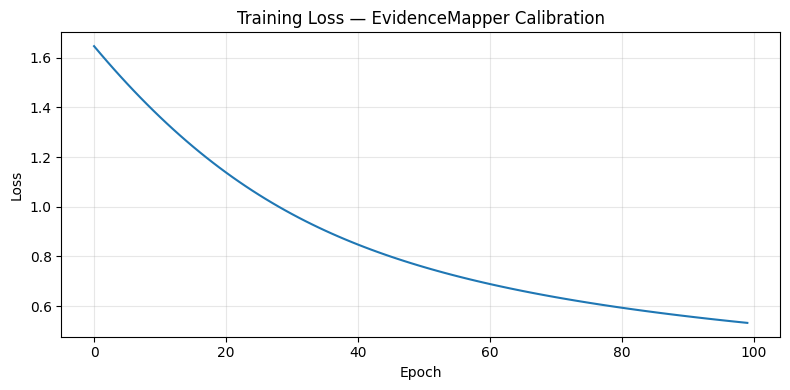

In [7]:
# Visualise the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(result.loss_history, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss — EvidenceMapper Calibration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Map the same observation again — now the mapper is calibrated
state_after = mapper.map(X_train[0], labels=labels)
print("Single observation → belief state (after training):")
print(f"  probabilities: {state_after.probabilities}")
print(f"  true label:    {labels[y_train[0]]}")
print()
print("The mapper now produces belief states aligned with the evidence-outcome structure.")

Single observation → belief state (after training):
  probabilities: [0.78618567 0.09029122 0.12352311]
  true label:    strategy_a

The mapper now produces belief states aligned with the evidence-outcome structure.


## 4 — AttoModel: `predict_proba` and Full Workflow

The high-level `AttoModel` wraps the mapper, trainer, and measurement behind
a scikit-learn style API. `predict_proba` returns the full probability
distribution over strategies — not just the point prediction.

In [9]:
config = CoreConfig(
    state_dim=n_strategies,
    action_labels=labels,
)

model = AttoModel(core_config=config, measurement_method="argmax")
model.fit(X_train, y_train)

# Point predictions
predictions = model.predict(X_test)
print(f"Predictions (first 10): {predictions[:10]}")
print(f"Actual      (first 10): {y_test[:10]}")
print()

# Accuracy
accuracy = (predictions == y_test).mean()
print(f"Test accuracy: {accuracy:.3f}")

Predictions (first 10): [0 0 0 0 0 0 0 0 0 0]
Actual      (first 10): [0 1 1 0 0 2 0 0 1 2]

Test accuracy: 0.450


In [10]:
# Full probability distributions
probabilities = model.predict_proba(X_test)

print("predict_proba output (first 5 test samples):")
print()
for i in range(5):
    probs_str = "  ".join(f"{labels[j]}: {probabilities[i, j]:.3f}" for j in range(n_strategies))
    print(f"  Sample {i}: {probs_str}  → predicted: {labels[predictions[i]]}  actual: {labels[y_test[i]]}")
print()
print("predict_proba reveals the full belief state at collapse time.")
print("A confident decision has one dominant probability.")
print("An ambiguous decision has probability spread across strategies.")

predict_proba output (first 5 test samples):

  Sample 0: strategy_a: 0.333  strategy_b: 0.333  strategy_c: 0.333  → predicted: strategy_a  actual: strategy_a
  Sample 1: strategy_a: 0.333  strategy_b: 0.333  strategy_c: 0.333  → predicted: strategy_a  actual: strategy_b
  Sample 2: strategy_a: 0.333  strategy_b: 0.333  strategy_c: 0.333  → predicted: strategy_a  actual: strategy_b
  Sample 3: strategy_a: 0.333  strategy_b: 0.333  strategy_c: 0.333  → predicted: strategy_a  actual: strategy_a
  Sample 4: strategy_a: 0.333  strategy_b: 0.333  strategy_c: 0.333  → predicted: strategy_a  actual: strategy_a

predict_proba reveals the full belief state at collapse time.
A confident decision has one dominant probability.
An ambiguous decision has probability spread across strategies.


## 5 — Model Persistence: `save` and `load`

Trained models can be serialised to JSON and reloaded. The loaded model
produces identical predictions to the original.

In [11]:
import os
import tempfile

# Save to a temporary file
save_path = os.path.join(tempfile.gettempdir(), "atto_demo_model.json")
model.save(save_path)
print(f"Model saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path):,} bytes")

Model saved to: /var/folders/gy/g9wzr9q54bz0nndmcjw6fq580000gn/T/atto_demo_model.json
File size: 406 bytes


In [12]:
# Load and verify
loaded = AttoModel.load(save_path)

loaded_predictions = loaded.predict(X_test)
loaded_probs = loaded.predict_proba(X_test)

predictions_match = np.array_equal(predictions, loaded_predictions)
probs_match = np.allclose(probabilities, loaded_probs)

print(f"Predictions match: {predictions_match}")
print(f"Probabilities match: {probs_match}")
print()
print("The loaded model is a perfect replica of the original.")

Predictions match: True
Probabilities match: True

The loaded model is a perfect replica of the original.


In [13]:
# Clean up temporary file
os.remove(save_path)
print(f"Cleaned up: {save_path}")

Cleaned up: /var/folders/gy/g9wzr9q54bz0nndmcjw6fq580000gn/T/atto_demo_model.json


## Summary

| Component | Role |
|-----------|------|
| `EvidenceMapper` | Linear projection from features to belief states |
| `AttoTrainer` | Calibrates the mapper via mini-batch gradient descent |
| `TrainingConfig` | Controls learning rate, epochs, batch size, seed |
| `model.predict()` | Point predictions (collapsed action indices) |
| `model.predict_proba()` | Full probability distributions at collapse time |
| `model.save()` / `.load()` | JSON serialisation and exact reconstruction |

Key takeaways:
- **The mapper is the bridge** between raw evidence and the QDE framework — it learns which feature patterns correspond to which belief states
- **`predict_proba` reveals uncertainty** — a confident decision has a peaked distribution, an ambiguous one is spread across strategies
- **Persistence is exact** — the loaded model produces identical predictions and probability distributions